<a href="https://colab.research.google.com/github/yusraanwar33-source/Deep-learning/blob/main/Loan_Approval_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loan Approval Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(42)

data = {
    'Loan_ID': ['LP00' + str(i) for i in range(101, 401)],
    'Gender': np.random.choice(['Male', 'Female'], 300),
    'Married': np.random.choice(['Yes', 'No'], 300),
    'Dependents': np.random.choice(['0', '1', '2', '3+'], 300),
    'Education': np.random.choice(['Graduate', 'Not Graduate'], 300),
    'Self_Employed': np.random.choice(['Yes', 'No'], 300),
    'ApplicantIncome': np.random.randint(1500, 10000, 300),
    'CoapplicantIncome': np.random.randint(0, 5000, 300),
    'LoanAmount': np.random.randint(90, 700, 300),
    'Loan_Amount_Term': np.random.choice([12, 36, 60, 120, 180, 240, 360], 300),
    'Credit_History': np.random.choice([0, 1], 300),
    'Property_Area': np.random.choice(['Urban', 'Semiurban', 'Rural'], 300),
    'Loan_Status': np.random.choice(['Y', 'N'], 300)
}

df = pd.DataFrame(data)
display(df.head())

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP00101,Male,Yes,0,Graduate,Yes,3470,2419,409,60,1,Semiurban,Y
1,LP00102,Female,Yes,3+,Not Graduate,No,9889,934,427,180,0,Urban,Y
2,LP00103,Male,Yes,3+,Not Graduate,No,7265,3042,455,360,1,Rural,N
3,LP00104,Male,No,1,Graduate,No,2702,4497,584,120,1,Semiurban,N
4,LP00105,Male,No,2,Graduate,Yes,9635,1466,696,60,0,Urban,N


In [3]:
print(df.info())
display(df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Loan_ID            300 non-null    object
 1   Gender             300 non-null    object
 2   Married            300 non-null    object
 3   Dependents         300 non-null    object
 4   Education          300 non-null    object
 5   Self_Employed      300 non-null    object
 6   ApplicantIncome    300 non-null    int64 
 7   CoapplicantIncome  300 non-null    int64 
 8   LoanAmount         300 non-null    int64 
 9   Loan_Amount_Term   300 non-null    int64 
 10  Credit_History     300 non-null    int64 
 11  Property_Area      300 non-null    object
 12  Loan_Status        300 non-null    object
dtypes: int64(5), object(8)
memory usage: 30.6+ KB
None


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,300,300,300,300,300,300,300.000000,300.000000,300.000000,300.000000,300.000000,300,300
unique,300,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP00400,Male,No,0,Graduate,Yes,NaN,NaN,NaN,NaN,NaN,Semiurban,N
freq,1,151,163,89,158,152,NaN,NaN,NaN,NaN,NaN,104,161
mean,NaN,NaN,NaN,NaN,NaN,NaN,5866.630000,2451.930000,383.790000,140.840000,0.510000,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,2374.656495,1437.353914,173.477551,113.825489,0.500735,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,1554.000000,2.000000,90.000000,12.000000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,3908.500000,1122.750000,233.500000,36.000000,0.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,5742.500000,2411.000000,392.500000,120.000000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,7808.750000,3677.250000,514.500000,240.000000,1.000000,NaN,NaN


## Data Preprocessing

In [4]:
# Drop Loan_ID column as it is not needed for prediction
df = df.drop('Loan_ID', axis=1)

# Convert 'Dependents' to numerical. Replace '3+' with '3' and then convert to int.
df['Dependents'] = df['Dependents'].replace('3+', '3').astype(int)

# Map Loan_Status to numerical (Y=1, N=0)
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

# One-hot encode remaining categorical features
df_processed = pd.get_dummies(df, columns=['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area'], drop_first=True)

display(df_processed.head())

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,3470,2419,409,60,1,1,True,True,False,True,True,False
1,3,9889,934,427,180,0,1,False,True,True,False,False,True
2,3,7265,3042,455,360,1,0,True,True,True,False,False,False
3,1,2702,4497,584,120,1,0,True,False,False,False,True,False
4,2,9635,1466,696,60,0,0,True,False,False,True,False,True


In [5]:
print(df_processed.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Dependents               300 non-null    int64
 1   ApplicantIncome          300 non-null    int64
 2   CoapplicantIncome        300 non-null    int64
 3   LoanAmount               300 non-null    int64
 4   Loan_Amount_Term         300 non-null    int64
 5   Credit_History           300 non-null    int64
 6   Loan_Status              300 non-null    int64
 7   Gender_Male              300 non-null    bool 
 8   Married_Yes              300 non-null    bool 
 9   Education_Not Graduate   300 non-null    bool 
 10  Self_Employed_Yes        300 non-null    bool 
 11  Property_Area_Semiurban  300 non-null    bool 
 12  Property_Area_Urban      300 non-null    bool 
dtypes: bool(6), int64(7)
memory usage: 18.3 KB
None


## Data Splitting and Model Training Preparation

## Exploratory Data Analysis (EDA) - Feature Relationships

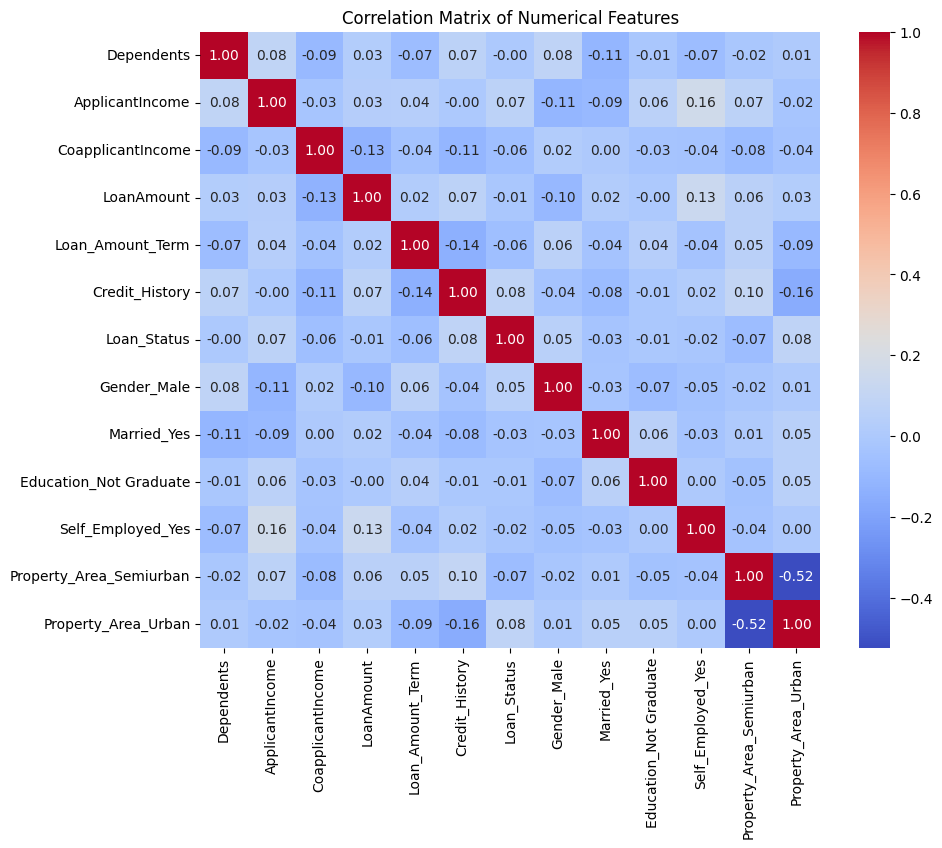

In [6]:
# Calculate the correlation matrix for numerical features
correlation_matrix = df_processed.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Impact of Features on Loan Status

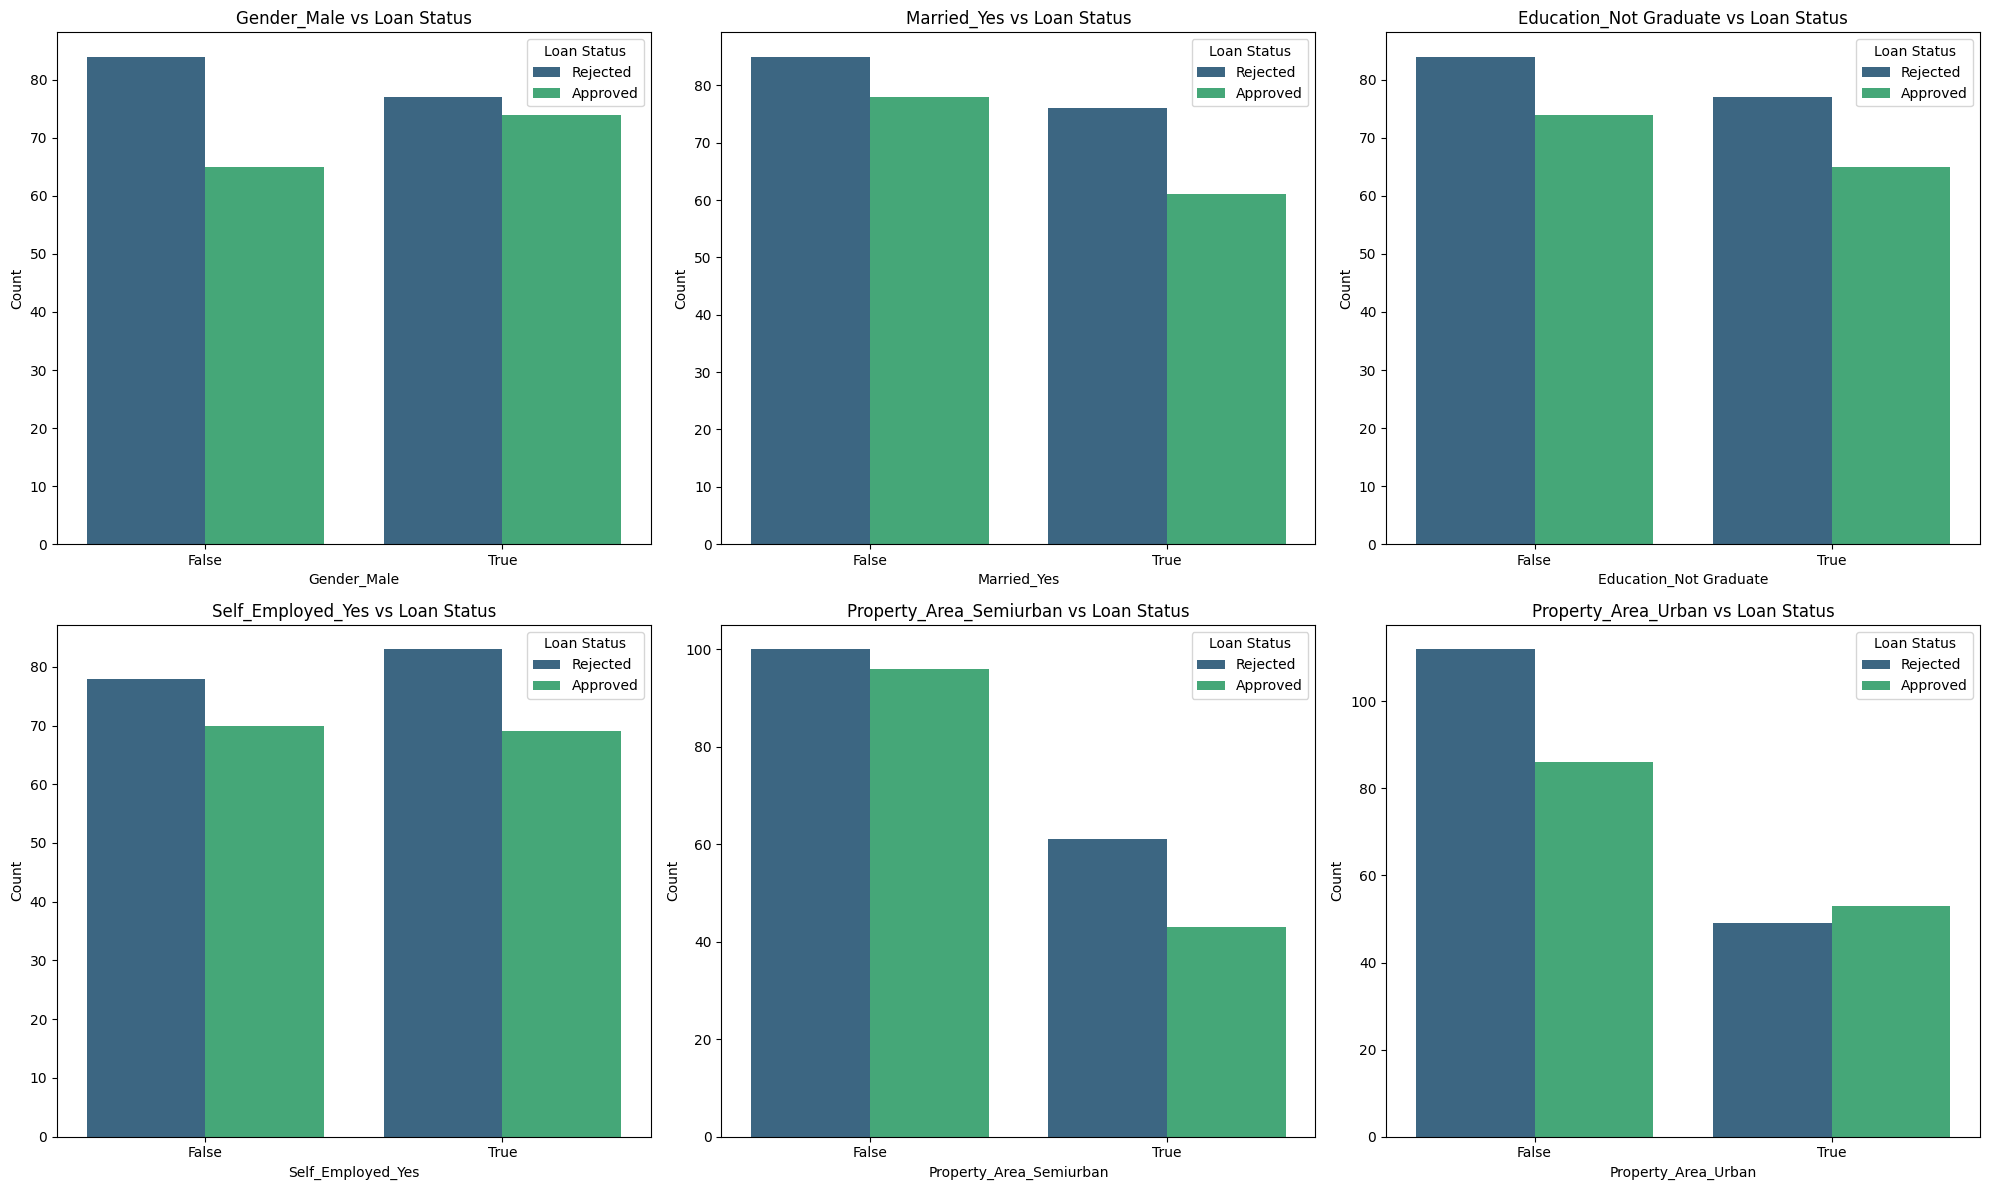

In [7]:
# Analyze the relationship between categorical features and Loan_Status
categorical_cols = ['Gender_Male', 'Married_Yes', 'Education_Not Graduate', 'Self_Employed_Yes', 'Property_Area_Semiurban', 'Property_Area_Urban']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, hue='Loan_Status', data=df_processed, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col} vs Loan Status')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Loan Status', labels=['Rejected', 'Approved'])

plt.tight_layout()
plt.show()

/tmp/ipykernel_1157/705995874.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Loan_Status', y=col, data=df_processed, palette='coolwarm')
/tmp/ipykernel_1157/705995874.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Loan_Status', y=col, data=df_processed, palette='coolwarm')
/tmp/ipykernel_1157/705995874.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Loan_Status', y=col, data=df_processed, palette='coolwarm')
/tmp/ipykernel_1157/705995874.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and

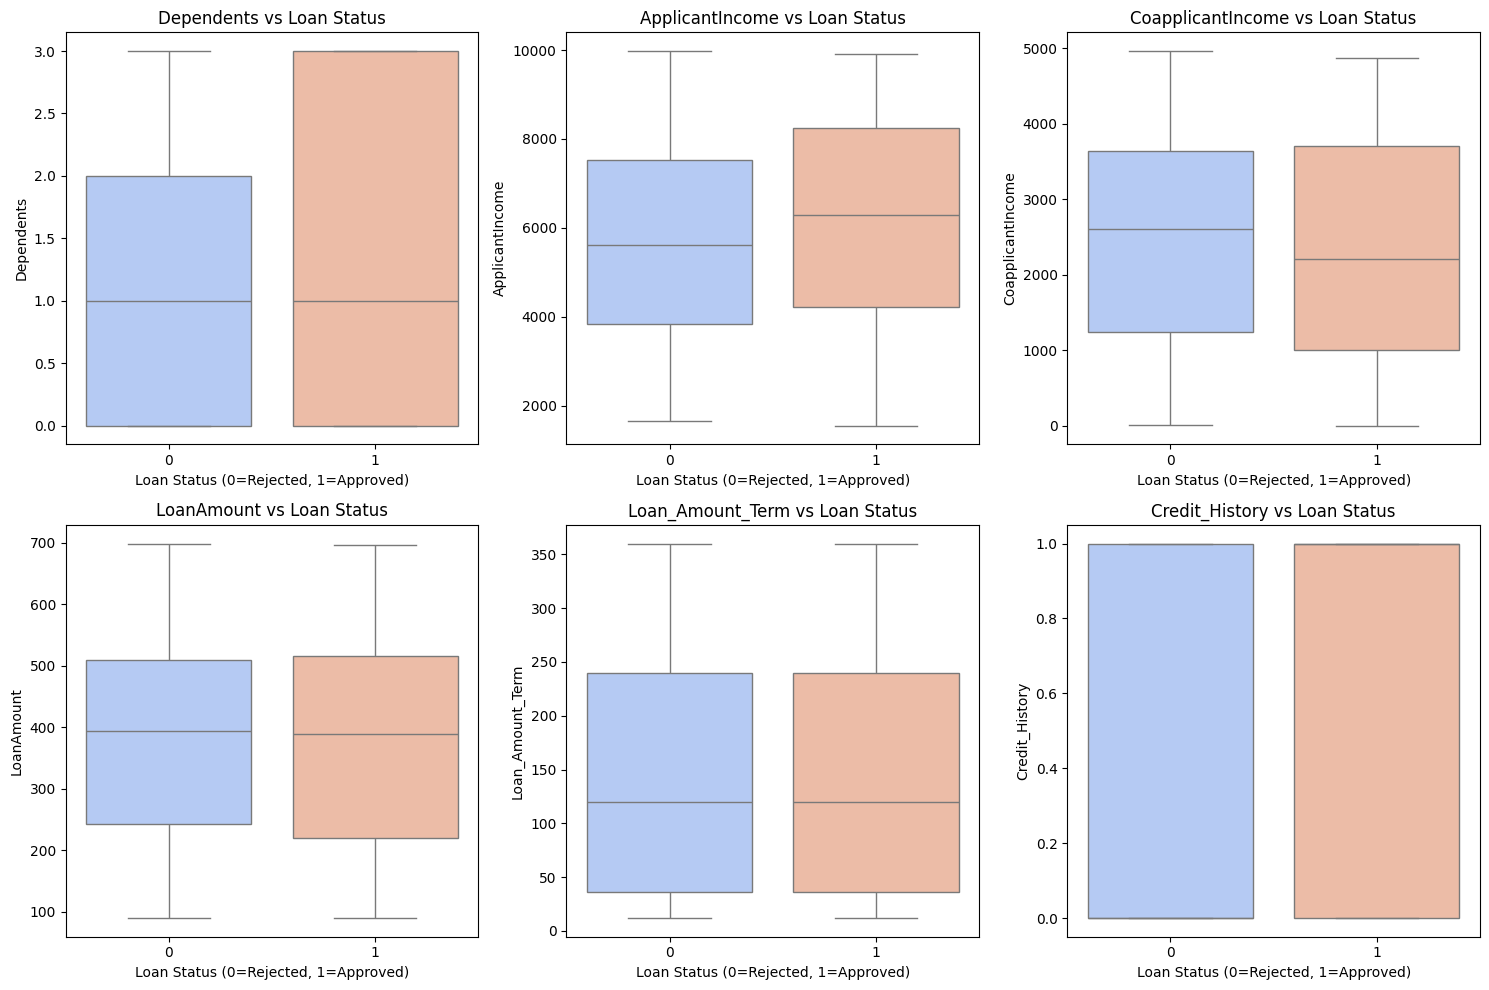

In [8]:
# Analyze the relationship between numerical features and Loan_Status (using mean)

numerical_cols = ['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x='Loan_Status', y=col, data=df_processed, palette='coolwarm')
    plt.title(f'{col} vs Loan Status')
    plt.xlabel('Loan Status (0=Rejected, 1=Approved)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### Feature Distributions

/tmp/ipykernel_1157/1045599802.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_processed[col], kde=True, bins=20, palette='crest')
/tmp/ipykernel_1157/1045599802.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_processed[col], kde=True, bins=20, palette='crest')
/tmp/ipykernel_1157/1045599802.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_processed[col], kde=True, bins=20, palette='crest')
/tmp/ipykernel_1157/1045599802.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_processed[col], kde=True, bins=20, palette='crest')
/tmp/ipykernel_1157/1045599802.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_processed[col], kde=True, bins=20, palette='crest')


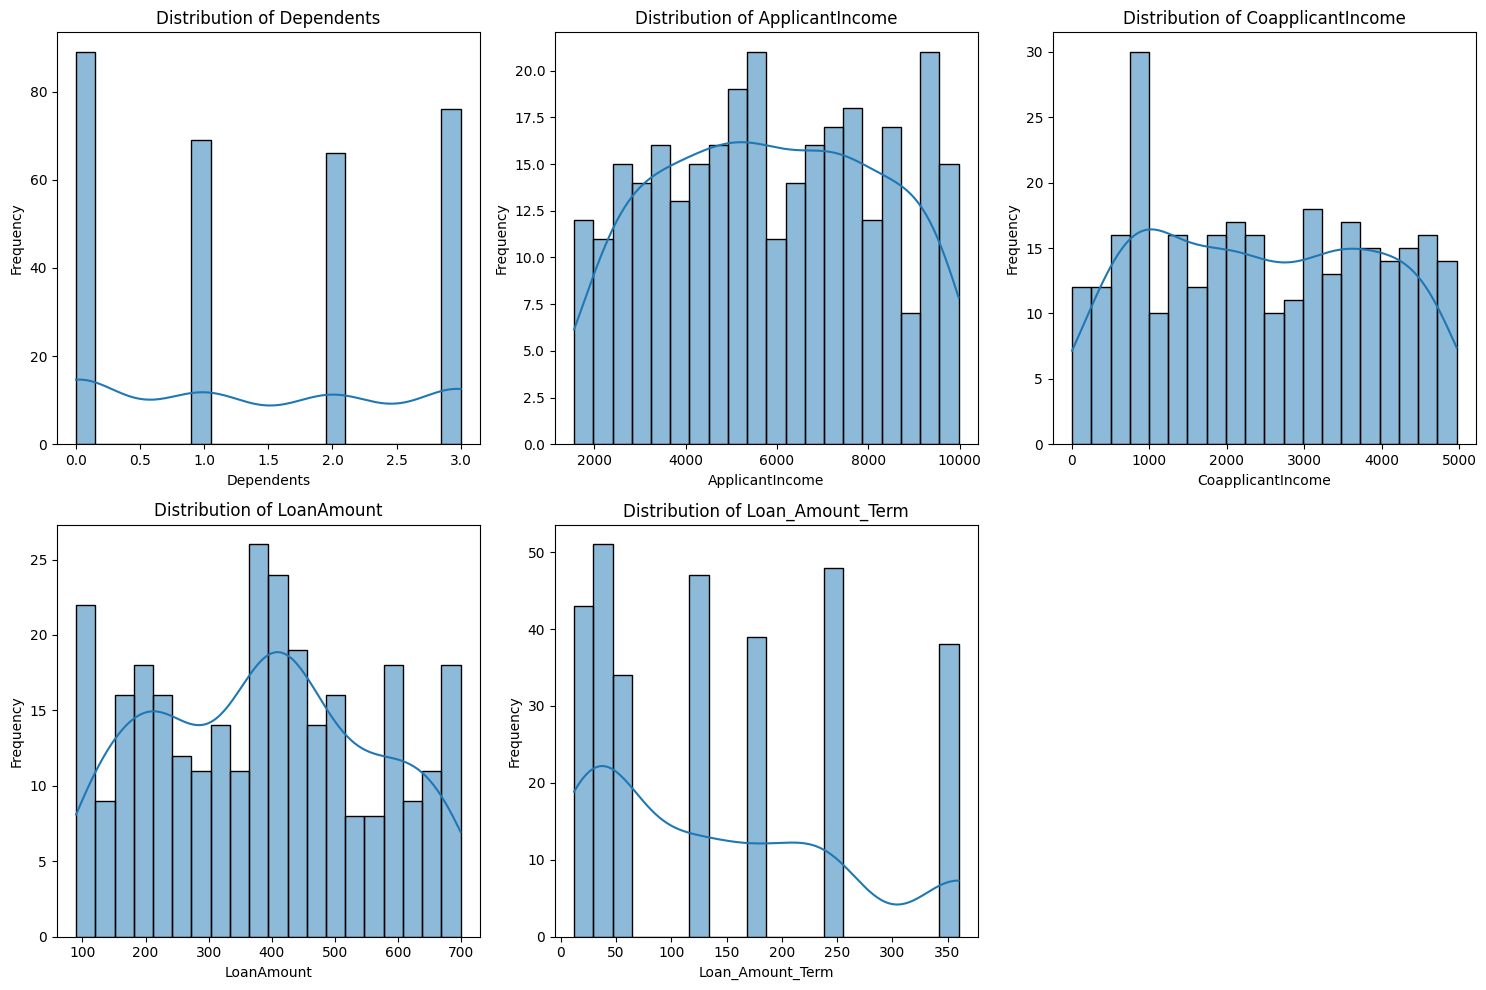

In [9]:
# Visualize distributions of numerical features
numerical_cols = ['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df_processed[col], kde=True, bins=20, palette='crest')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [ ]:
# Visualize distributions of categorical features
categorical_cols_original = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']

plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols_original):
    plt.subplot(2, 3, i + 1)
    sns.countplot(x=col, data=df, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Model Training and Evaluation

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Split data into features (X) and target (y)
X = df_processed.drop('Loan_Status', axis=1)
y = df_processed['Loan_Status']

# Convert boolean columns to integer (0 or 1) for model compatibility
X = X.astype(int)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # Using 'liblinear' solver for small datasets
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


### Model Prediction and Evaluation

Accuracy: 0.57

Confusion Matrix:
 [[23  7]
 [19 11]]

Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.77      0.64        30
           1       0.61      0.37      0.46        30

    accuracy                           0.57        60
   macro avg       0.58      0.57      0.55        60
weighted avg       0.58      0.57      0.55        60



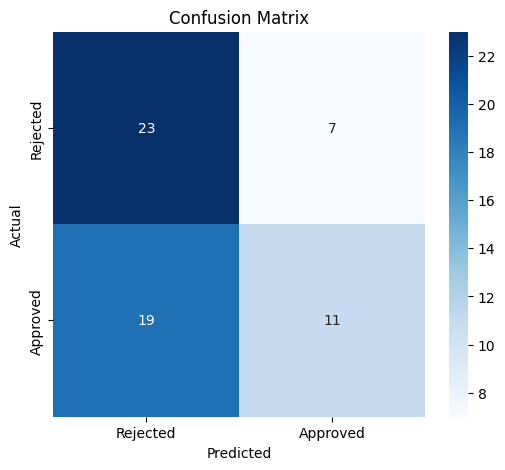

In [11]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Approved'], yticklabels=['Rejected', 'Approved'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Random Forest Classifier - Training and Evaluation

In [12]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest model training complete.")

Random Forest model training complete.


### Random Forest Model Prediction and Evaluation

Random Forest Accuracy: 0.43

Random Forest Confusion Matrix:
 [[19 11]
 [23  7]]

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.45      0.63      0.53        30
           1       0.39      0.23      0.29        30

    accuracy                           0.43        60
   macro avg       0.42      0.43      0.41        60
weighted avg       0.42      0.43      0.41        60



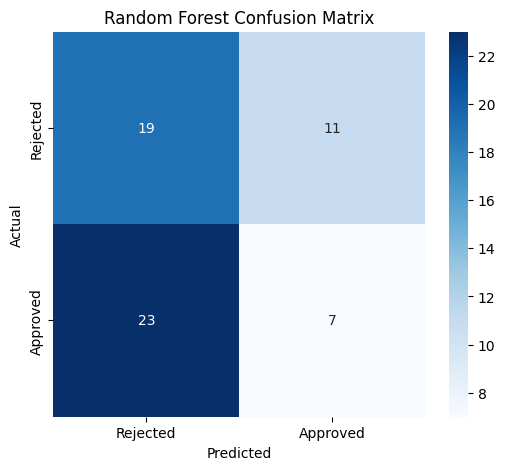

In [13]:
# Make predictions on the test set using Random Forest
y_pred_rf = rf_model.predict(X_test)

# Evaluate the Random Forest model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
class_report_rf = classification_report(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.2f}")
print("\nRandom Forest Confusion Matrix:\n", conf_matrix_rf)
print("\nRandom Forest Classification Report:\n", class_report_rf)

# Plot Confusion Matrix for Random Forest
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Approved'], yticklabels=['Rejected', 'Approved'])
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Model Comparison

In [14]:
print("--- Logistic Regression Model Performance ---")
print(f"Accuracy: {accuracy:.2f}")
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

print("\n--- Random Forest Classifier Performance ---")
print(f"Accuracy: {accuracy_rf:.2f}")
print("Confusion Matrix:\n", conf_matrix_rf)
print("Classification Report:\n", class_report_rf)

# You can add further comparative analysis here, for example:
# - Compare specific metrics like precision, recall, F1-score for each class.
# - Discuss which model is better suited based on the business problem (e.g., minimizing false negatives for loan approval).

--- Logistic Regression Model Performance ---
Accuracy: 0.57
Confusion Matrix:
 [[23  7]
 [19 11]]
Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.77      0.64        30
           1       0.61      0.37      0.46        30

    accuracy                           0.57        60
   macro avg       0.58      0.57      0.55        60
weighted avg       0.58      0.57      0.55        60


--- Random Forest Classifier Performance ---
Accuracy: 0.43
Confusion Matrix:
 [[19 11]
 [23  7]]
Classification Report:
               precision    recall  f1-score   support

           0       0.45      0.63      0.53        30
           1       0.39      0.23      0.29        30

    accuracy                           0.43        60
   macro avg       0.42      0.43      0.41        60
weighted avg       0.42      0.43      0.41        60

